# Step 8: Regime Analysis & Stress Testing


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join('..', 'Src')))

from evaluation.stability_analysis import (
    classify_volatility_regime,
    classify_trend_regime,
    classify_drawdown_regime,
    evaluate_by_regime,
    stress_test_model
)
from evaluation.metrics import compute_roc_auc

PROCESSED_DIR = os.path.join('..', 'Data', 'Processed')
FIGURES_DIR = os.path.join('..', 'Reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete.")

Setup complete.


---
## 1. Load Data

In [2]:
# Load predictions and modeling dataset
predictions = pd.read_csv(os.path.join(PROCESSED_DIR, 'baseline_predictions.csv'), parse_dates=['date'])
modeling_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'modeling_dataset.csv'), parse_dates=['date'])

# Merge to get log_return for regime classification
df = predictions.merge(modeling_df[['date', 'ticker', 'log_return']], on=['date', 'ticker'], how='left')

print(f"Samples: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Samples: 1,564
Date range: 2024-10-08 to 2026-01-07


---
## 2. Define Market Regimes

In [3]:
# Classify regimes
df['vol_regime'] = classify_volatility_regime(df, 'log_return', window=21)
df['trend_regime'] = classify_trend_regime(df, 'log_return', window=63)
df['drawdown_regime'] = classify_drawdown_regime(df, 'log_return', threshold=-0.1)

print("Regime Distribution:")
print(f"\nVolatility: {df['vol_regime'].value_counts().to_dict()}")
print(f"Trend:      {df['trend_regime'].value_counts().to_dict()}")
print(f"Drawdown:   {df['drawdown_regime'].value_counts().to_dict()}")

Regime Distribution:

Volatility: {'low_vol': 786, 'high_vol': 778}
Trend:      {'bull': 1015, 'bear': 549}
Drawdown:   {'drawdown': 928, 'normal': 636}


---
## 3. Performance by Regime


In [4]:
models = {'Logistic Regression': 'lr_prob', 'Decision Tree': 'dt_prob', 'Random Forest': 'rf_prob'}
regimes = ['vol_regime', 'trend_regime', 'drawdown_regime']

all_results = []

for regime_type in regimes:
    for model_name, prob_col in models.items():
        result = evaluate_by_regime(df, 'target', prob_col, regime_type)
        result['model'] = model_name
        result['regime_type'] = regime_type
        all_results.append(result)

regime_results = pd.concat(all_results, ignore_index=True)
print(regime_results.to_string(index=False))

  regime  n_samples   metric  positive_rate               model     regime_type
 low_vol        786 0.486060       0.446565 Logistic Regression      vol_regime
high_vol        778 0.590115       0.480720 Logistic Regression      vol_regime
 low_vol        786 0.488967       0.446565       Decision Tree      vol_regime
high_vol        778 0.553466       0.480720       Decision Tree      vol_regime
 low_vol        786 0.504601       0.446565       Random Forest      vol_regime
high_vol        778 0.611634       0.480720       Random Forest      vol_regime
    bear        549 0.553054       0.378871 Logistic Regression    trend_regime
    bull       1015 0.540001       0.509360 Logistic Regression    trend_regime
    bear        549 0.521233       0.378871       Decision Tree    trend_regime
    bull       1015 0.519645       0.509360       Decision Tree    trend_regime
    bear        549 0.576246       0.378871       Random Forest    trend_regime
    bull       1015 0.540885       0.509

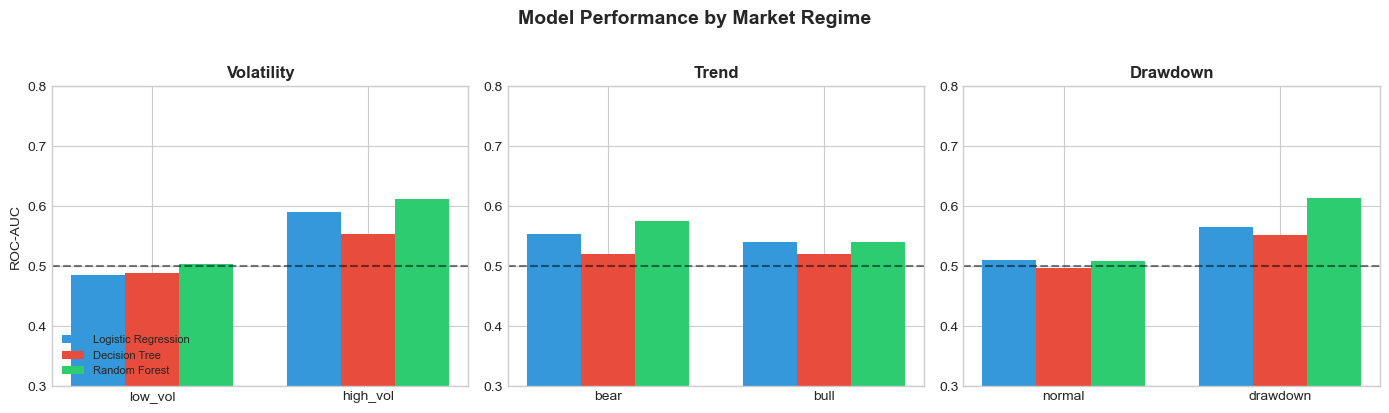

Saved: regime_comparison.png


In [5]:
# Visualize regime performance
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = {'Logistic Regression': '#3498db', 'Decision Tree': '#e74c3c', 'Random Forest': '#2ecc71'}
regime_labels = {'vol_regime': 'Volatility', 'trend_regime': 'Trend', 'drawdown_regime': 'Drawdown'}

for i, regime_type in enumerate(regimes):
    ax = axes[i]
    subset = regime_results[regime_results['regime_type'] == regime_type]
    
    regime_names = subset['regime'].unique()
    x = np.arange(len(regime_names))
    width = 0.25
    
    for j, (model_name, _) in enumerate(models.items()):
        model_data = subset[subset['model'] == model_name]
        vals = [model_data[model_data['regime'] == r]['metric'].values[0] 
                if len(model_data[model_data['regime'] == r]) > 0 else 0.5 
                for r in regime_names]
        ax.bar(x + j*width, vals, width, label=model_name if i == 0 else '', color=colors[model_name])
    
    ax.axhline(y=0.5, color='k', linestyle='--', alpha=0.5)
    ax.set_ylabel('ROC-AUC' if i == 0 else '')
    ax.set_title(regime_labels[regime_type], fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(regime_names)
    ax.set_ylim([0.3, 0.8])

axes[0].legend(loc='lower left', fontsize=8)
plt.suptitle('Model Performance by Market Regime', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'regime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regime_comparison.png")

---
## 4. Stress Testing


In [6]:
print("="*60)
print("STRESS TEST RESULTS")
print("="*60)

y_true = df['target'].values

stress_results = []
for model_name, prob_col in models.items():
    y_prob = df[prob_col].values
    result = stress_test_model(y_true, y_prob)
    result['model'] = model_name
    stress_results.append(result)
    
    print(f"\n{model_name}:")
    for _, row in result.iterrows():
        print(f"  {row['scenario']:<18} AUC: {row['metric']:.4f}")

stress_df = pd.concat(stress_results, ignore_index=True)

STRESS TEST RESULTS

Logistic Regression:
  baseline           AUC: 0.5408
  vol_spike_1.5x     AUC: 0.5408
  vol_spike_2x       AUC: 0.5408
  noise_10%          AUC: 0.5255
  noise_20%          AUC: 0.5219

Decision Tree:
  baseline           AUC: 0.5215
  vol_spike_1.5x     AUC: 0.5191
  vol_spike_2x       AUC: 0.5191
  noise_10%          AUC: 0.5174
  noise_20%          AUC: 0.5232

Random Forest:
  baseline           AUC: 0.5584
  vol_spike_1.5x     AUC: 0.5584
  vol_spike_2x       AUC: 0.5584
  noise_10%          AUC: 0.5307
  noise_20%          AUC: 0.5237


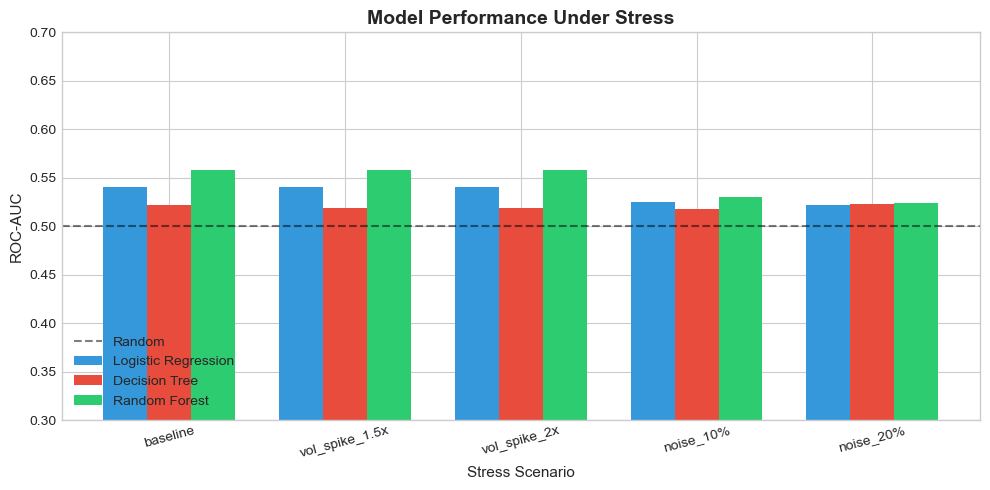

In [7]:
# Visualize stress test results
fig, ax = plt.subplots(figsize=(10, 5))

scenarios = stress_df['scenario'].unique()
x = np.arange(len(scenarios))
width = 0.25

for i, (model_name, _) in enumerate(models.items()):
    model_data = stress_df[stress_df['model'] == model_name]
    vals = [model_data[model_data['scenario'] == s]['metric'].values[0] for s in scenarios]
    ax.bar(x + i*width, vals, width, label=model_name, color=colors[model_name])

ax.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Random')
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_xlabel('Stress Scenario', fontsize=11)
ax.set_title('Model Performance Under Stress', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(scenarios, rotation=15)
ax.legend(loc='lower left')
ax.set_ylim([0.3, 0.7])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'stress_test_results.png'), dpi=150)
plt.show()

---
## 5. Where Should the Model NOT Be Used?

In [ ]:
print("\n" + "="*70)
print("REGIME ANALYSIS CONCLUSIONS")
print("="*70)

# Find weak regimes (AUC < 0.52 or significantly below baseline)
warnings = []

for model_name, prob_col in models.items():
    model_results = regime_results[regime_results['model'] == model_name]
    baseline_auc = compute_roc_auc(df['target'], df[prob_col])
    
    print(f"\n{model_name} (Baseline AUC: {baseline_auc:.3f}):")
    
    for _, row in model_results.iterrows():
        status = '✓' if row['metric'] > 0.52 else '✗'
        diff = row['metric'] - baseline_auc
        print(f"  {row['regime']:<12} AUC: {row['metric']:.3f} ({diff:+.3f}) {status}")
        
        if row['metric'] < 0.52:
            warnings.append(f"{model_name} in {row['regime']} regime")

print("\n" + "="*70)
print("⚠️  USAGE WARNINGS")
print("="*70)
if warnings:
    print("\nDo NOT rely on predictions in these conditions:")
    for w in warnings:
        print(f"  • {w}")
else:
    print("\nNo critical regime failures detected.")

print("\n" + "="*70)
print("STRESS TEST CONCLUSIONS")
print("="*70)

for model_name in models.keys():
    model_stress = stress_df[stress_df['model'] == model_name]
    baseline = model_stress[model_stress['scenario'] == 'baseline']['metric'].values[0]
    worst = model_stress['metric'].min()
    degradation = (baseline - worst) / baseline * 100
    
    print(f"\n{model_name}:")
    print(f"  Baseline:    {baseline:.3f}")
    print(f"  Worst case:  {worst:.3f}")
    print(f"  Degradation: {degradation:.1f}%")
    
    if degradation > 20:
        print(f"  ⚠️  HIGH sensitivity to stress conditions")
    elif degradation > 10:
        print(f"  ⚡ Moderate sensitivity to stress")
    else:
        print(f"  ✓ Robust under stress")


REGIME ANALYSIS CONCLUSIONS

Logistic Regression (Baseline AUC: 0.541):
  low_vol      AUC: 0.486 (-0.055) ✗
  high_vol     AUC: 0.590 (+0.049) ✓
  bear         AUC: 0.553 (+0.012) ✓
  bull         AUC: 0.540 (-0.001) ✓
  normal       AUC: 0.510 (-0.030) ✗
  drawdown     AUC: 0.566 (+0.025) ✓

Decision Tree (Baseline AUC: 0.522):
  low_vol      AUC: 0.489 (-0.033) ✗
  high_vol     AUC: 0.553 (+0.032) ✓
  bear         AUC: 0.521 (-0.000) ✓
  bull         AUC: 0.520 (-0.002) ✗
  normal       AUC: 0.497 (-0.024) ✗
  drawdown     AUC: 0.552 (+0.031) ✓

Random Forest (Baseline AUC: 0.558):
  low_vol      AUC: 0.505 (-0.054) ✗
  high_vol     AUC: 0.612 (+0.053) ✓
  bear         AUC: 0.576 (+0.018) ✓
  bull         AUC: 0.541 (-0.018) ✓
  normal       AUC: 0.508 (-0.050) ✗
  drawdown     AUC: 0.613 (+0.055) ✓

⚠️  USAGE WARNINGS

Do NOT rely on predictions in these conditions:
  • Logistic Regression in low_vol regime
  • Logistic Regression in normal regime
  • Decision Tree in low_vol regi